In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import fbeta_score, classification_report, make_scorer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy
from tqdm import tqdm
from scipy.optimize import minimize
import gc

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cuda


In [2]:
train_path = './train.csv'
A_path = './A.csv'
B_path = './B.csv'

train_df = pd.read_csv(train_path)
A_df = pd.read_csv(A_path)
B_df = pd.read_csv(B_path)

print(f"训练集大小: {len(train_df)}")
print(f"A榜测试集大小: {len(A_df)}")
print(f"B榜测试集大小: {len(B_df)}")
train_df.head()

训练集大小: 30000
A榜测试集大小: 30000
B榜测试集大小: 30000


,objid,ra,dec,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,type
0,1237668504903614866,249.490153,55.151437,23.68451,21.39811,20.67514,19.99474,19.68875,GALAXY
1,1237678905705496902,352.319214,9.039377,25.50177,22.23817,20.35363,-9999.00000,19.04753,GALAXY
2,1237665129620177669,191.973058,35.668576,23.29363,23.13536,21.54516,20.33303,19.59550,GALAXY
3,1237665373868262174,235.781533,22.548614,23.39743,-9999.00000,20.76465,19.92709,-9999.00000,GALAXY
4,1237679322324074909,34.061757,-5.148214,-9999.00000,-9999.00000,20.99208,20.32286,19.83057,GALAXY


=== 数据类型 ===
objid           int64
ra            float64
dec           float64
modelMag_u    float64
modelMag_g    float64
modelMag_r    float64
modelMag_i    float64
modelMag_z    float64
type           object
dtype: object

=== 缺失值统计 ===
objid         0
ra            0
dec           0
modelMag_u    0
modelMag_g    0
modelMag_r    0
modelMag_i    0
modelMag_z    0
type          0
dtype: int64

=== 标签分布 ===
type
GALAXY    21000
STAR       4500
QSO        4500
Name: count, dtype: int64

类别比例:
type
GALAXY    0.70
STAR      0.15
QSO       0.15
Name: proportion, dtype: float64


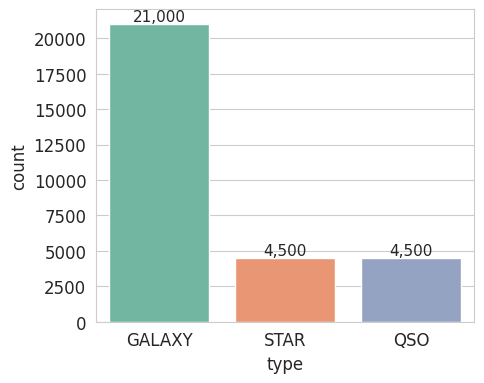

In [3]:
print("=== 数据类型 ===")
print(train_df.dtypes)
print("\n=== 缺失值统计 ===")
print(train_df.isnull().sum())
print("\n=== 标签分布 ===")
print(train_df['type'].value_counts())
print(f"\n类别比例:\n{train_df['type'].value_counts(normalize=True)}")

plt.figure(figsize=(5, 4))
ax = sns.countplot(data=train_df, x='type', palette='Set2', order=['GALAXY', 'STAR', 'QSO'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

In [4]:
feature_cols = ['modelMag_u', 'modelMag_g', 'modelMag_r', 'modelMag_i', 'modelMag_z']

In [5]:
print(train_df[feature_cols].describe())

         modelMag_u    modelMag_g    modelMag_r    modelMag_i    modelMag_z
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000
mean   -1970.349611  -1993.943279  -1952.050643  -1976.579710  -2006.903242
std     3999.751427   4015.933072   3983.265384   4001.246592   4023.570024
min    -9999.000000  -9999.000000  -9999.000000  -9999.000000  -9999.000000
25%       18.752175     17.307368     16.628947     16.200378     15.883073
50%       21.530845     20.343485     19.252940     18.676625     18.290180
75%       23.411815     21.981660     20.793453     19.958317     19.529242
max       28.273960     31.669520     32.199950     26.431710     27.631240


In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

def clean_magnitudes_iterative(df, mag_cols):
    """
    针对 SDSS 测光数据的迭代清洗：
    1. 将异常标记 (-9999、饱和、宇宙线) 替换为 NaN
    2. 构造缺失指示特征 (可选)
    3. 用 IterativeImputer (RandomForestRegressor) 填充 NaN
    """
    df_clean = df.copy()

    # ---------- 第一步：将各类异常值统一替换为 NaN ----------
    for col in mag_cols:
        # 空值标记
        df_clean[col] = df_clean[col].replace(-9999.0, np.nan)
        # 仪器饱和 (星等 < 5 通常不可能，且排除 NaN)
        df_clean.loc[(df_clean[col] < 5) & (df_clean[col].notna()), col] = np.nan
        # 宇宙线 / 坏像素 (星等 > 40 极暗)
        df_clean.loc[(df_clean[col] > 40) & (df_clean[col].notna()), col] = np.nan

    # ---------- 第二步：构造缺失指示特征 ----------
    for col in mag_cols:
        df_clean[col + '_was_missing'] = df_clean[col].isna().astype(int)

    # ---------- 第三步：迭代填充 ----------
    # 确定要进行填充的数值列：星等列 + 缺失指示列（都是数值）
    fill_cols = mag_cols + [col + '_was_missing' for col in mag_cols]

    # 分离非填充列（如 objid, type 等）
    other_cols = [c for c in df_clean.columns if c not in fill_cols]
    df_other = df_clean[other_cols].reset_index(drop=True)

    # 对填充列使用 IterativeImputer
    imp = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=10, random_state=42),
        max_iter=20,
        initial_strategy='median',
        random_state=42
    )
    filled_array = imp.fit_transform(df_clean[fill_cols])
    df_filled = pd.DataFrame(filled_array, columns=fill_cols)

    # 合并回非填充列，并恢复原始列顺序
    df_out = pd.concat([df_other, df_filled], axis=1)
    # 保持原列的顺序（先出现非填充列，再出现填充列）
    original_order = other_cols + fill_cols
    df_out = df_out[original_order]

    return df_out

# ---------- 应用清洗 ----------
feature_cols = ['modelMag_u', 'modelMag_g', 'modelMag_r', 'modelMag_i', 'modelMag_z']
train_clean = clean_magnitudes_iterative(train_df, feature_cols)
print(f"原始训练集: {len(train_df)}, 清洗后: {len(train_clean)}")

# 后续使用清洗后的数据
train_df = train_clean

原始训练集: 30000, 清洗后: 30000


使用的特征 (9 个): ['modelMag_u', 'modelMag_g', 'modelMag_r', 'modelMag_i', 'modelMag_z', 'u-g', 'g-r', 'r-i', 'i-z']


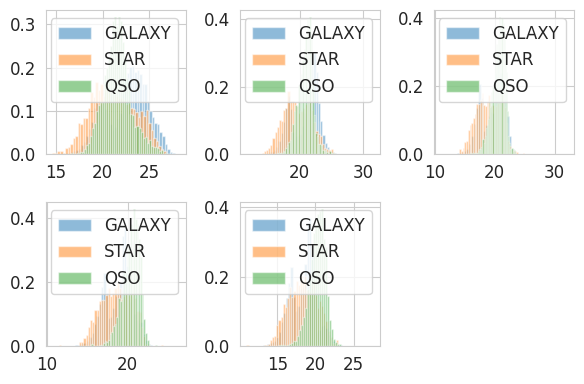

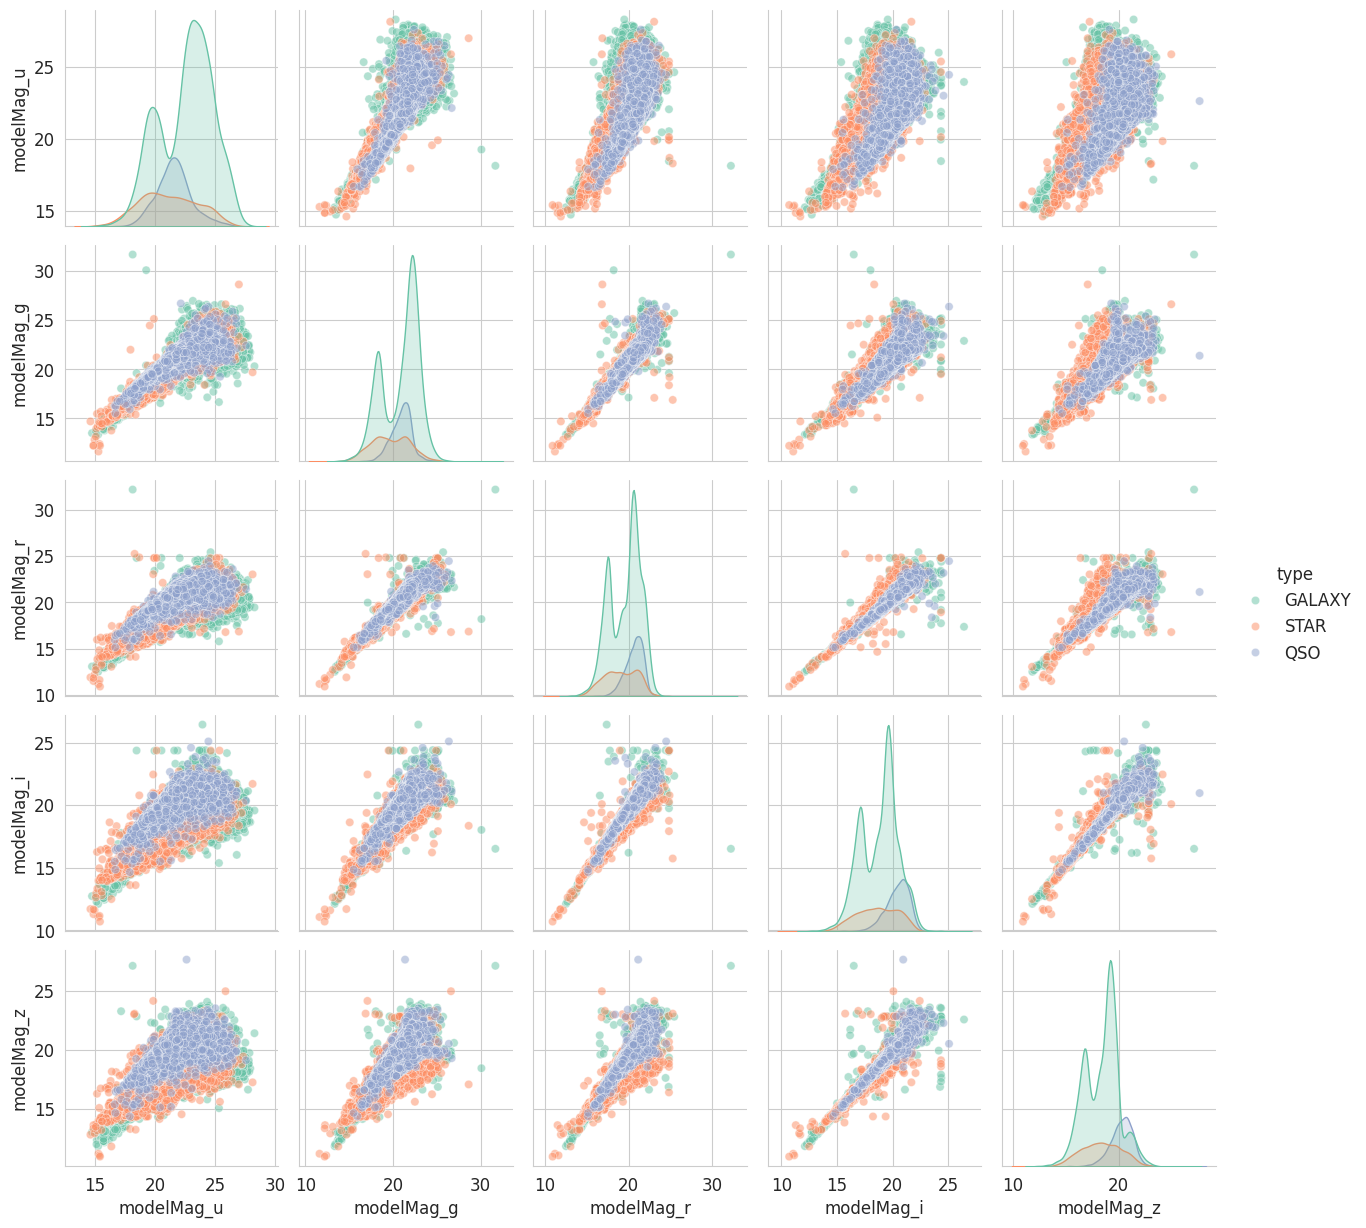

In [7]:
def add_color_features(df):
    df_new = df.copy()
    df_new['u-g'] = df_new['modelMag_u'] - df_new['modelMag_g']
    df_new['g-r'] = df_new['modelMag_g'] - df_new['modelMag_r']
    df_new['r-i'] = df_new['modelMag_r'] - df_new['modelMag_i']
    df_new['i-z'] = df_new['modelMag_i'] - df_new['modelMag_z']
    return df_new

train_fe = add_color_features(train_df)
A_fe = add_color_features(A_df)
B_fe = add_color_features(B_df)

color_cols = ['u-g', 'g-r', 'r-i', 'i-z']
base_features = feature_cols + color_cols
print(f"使用的特征 ({len(base_features)} 个): {base_features}")

fig, axes = plt.subplots(2, 3, figsize=(6, 4))
axes = axes.flatten()
for i, col in enumerate(base_features[:5]):
    for t in ['GALAXY', 'STAR', 'QSO']:
        subset = train_fe[train_fe['type'] == t][col]
        axes[i].hist(subset, bins=50, alpha=0.5, label=t, density=True)
    axes[i].legend()
axes[-1].axis('off')
plt.tight_layout()
plt.show()

sns.pairplot(train_fe, vars=base_features[:5], hue='type', palette='Set2', diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

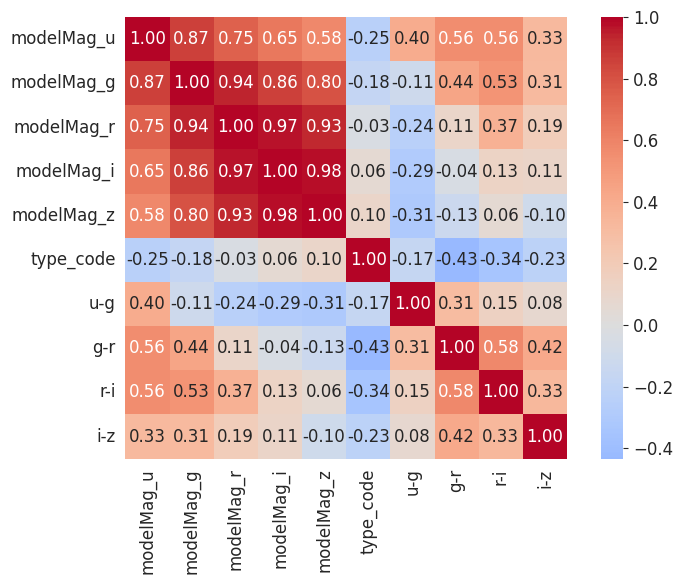

In [8]:
from copy import deepcopy

# 假设 train_df 已存在，且有 'modelMag_u/g/r/i/z' 和 'type' 列
sample_df = deepcopy(train_df)          # 统一用 sample_df

# 计算颜色列并添加到 DataFrame 中
sample_df['u-g'] = sample_df['modelMag_u'] - sample_df['modelMag_g']
sample_df['g-r'] = sample_df['modelMag_g'] - sample_df['modelMag_r']
sample_df['r-i'] = sample_df['modelMag_r'] - sample_df['modelMag_i']
sample_df['i-z'] = sample_df['modelMag_i'] - sample_df['modelMag_z']

# 对类型进行编码
le = LabelEncoder()
sample_df['type_code'] = le.fit_transform(sample_df['type'])

# 定义绘图所需列（现在颜色列已存在）
plot_cols = ['modelMag_u', 'modelMag_g', 'modelMag_r', 'modelMag_i', 'modelMag_z',
             'type_code', 'u-g', 'g-r', 'r-i', 'i-z']

# 计算相关矩阵并绘图
corr_matrix = sample_df[plot_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.tight_layout()
plt.show()

In [9]:
X = train_fe[base_features].values.astype(np.float32)
y = train_fe['type'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"标签映射: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

标签映射: {'GALAXY': 0, 'QSO': 1, 'STAR': 2}


In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.1, random_state=42, stratify=y_encoded
)
print(f"训练集大小: {len(X_train)}, 验证集大小: {len(X_val)}")

训练集大小: 27000, 验证集大小: 3000


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [12]:
class TabularTransformer(nn.Module):
    def __init__(self, num_features, d_model=2048, nhead=8, num_layers=8, dropout=0.1):
        super().__init__()
        self.num_features = num_features
        self.d_model = d_model

        self.feature_embedding = nn.Linear(1, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_embedding = nn.Parameter(torch.randn(1, num_features + 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Linear(d_model, d_model)
        )
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x):
        batch_size = x.size(0)
        x = x.unsqueeze(-1)
        x = self.feature_embedding(x)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        # x = x + self.pos_embedding

        x = self.transformer(x)
        cls_out = x[:, 0, :]
        return self.fc(cls_out)

In [13]:
gc.collect()
torch.cuda.empty_cache()

In [59]:
BATCH_SIZE = 128
EPOCHS = 100
LR = 5e-6
WEIGHT_DECAY = 1e-3
PATIENCE = 10

train_dataset = TensorDataset(torch.tensor(X_train_scaled), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val_scaled), torch.tensor(y_val, dtype=torch.long))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

pt_model = TabularTransformer(
    num_features=len(base_features),
    d_model=512, nhead=16, num_layers=4, dropout=0.2
).to(device)
pt_head = nn.Linear(pt_model.d_model, len(label_encoder.classes_)).to(device)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(
    list(pt_model.parameters()) + list(pt_head.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-7)

best_val_f2 = 0.0
best_model_state = None
best_head_state = None
patience_counter = 0

print('开始训练 Headless Transformer（用于特征提取）...')
for epoch in range(1, EPOCHS + 1):
    pt_model.train()
    pt_head.train()
    train_loss = 0.0
    for X_batch, y_batch in tqdm(train_loader):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
            features = pt_model(X_batch)
            logits = pt_head(features)
            loss = criterion(logits, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(pt_model.parameters(), max_norm=2.0)
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    pt_model.eval()
    pt_head.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
                features = pt_model(X_batch)
                logits = pt_head(features)
            preds = torch.argmax(logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(y_batch.cpu().numpy())

    val_f2 = fbeta_score(val_targets, val_preds, beta=2, average='weighted')
    scheduler.step(val_f2)

    print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | Val F2: {val_f2:.6f}")

    if val_f2 > best_val_f2 + 0.01:
        best_val_f2 = val_f2
        best_model_state = copy.deepcopy(pt_model.state_dict())
        best_head_state = copy.deepcopy(pt_head.state_dict())
        torch.save({'model': best_model_state, 'head': best_head_state}, 'best_model_state.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"早停触发，在第 {epoch} 轮停止训练。")
            break

pt_model.load_state_dict(best_model_state)
pt_head.load_state_dict(best_head_state)

# 提取 Transformer 特征并拼接回训练/验证数据
pt_model.eval()
pt_head.eval()
train_tfeat = []
val_tfeat = []
with torch.no_grad(), torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
    for batch in train_loader:
        train_tfeat.extend(pt_model(batch[0].to(device)).cpu().numpy())
    for batch in val_loader:
        val_tfeat.extend(pt_model(batch[0].to(device)).cpu().numpy())

train_tfeat = np.array(train_tfeat)
val_tfeat = np.array(val_tfeat)
X_train_aug = np.concatenate([X_train, train_tfeat], axis=1)
X_val_aug = np.concatenate([X_val, val_tfeat], axis=1)
print(f'增强后训练特征维度: {X_train_aug.shape[1]}')

print(f"Headless Transformer 训练完成，最佳验证 F2: {best_val_f2:.6f}")

开始训练 Headless Transformer（用于特征提取）...


100%|██████████| 211/211 [00:06<00:00, 31.54it/s]


Epoch  1 | Train Loss: 1.1747 | Val F2: 0.341132


100%|██████████| 211/211 [00:06<00:00, 32.89it/s]


Epoch  2 | Train Loss: 1.1567 | Val F2: 0.338301


...

Epoch 80 | Train Loss: 0.9340 | Val F2: 0.761695


100%|██████████| 211/211 [00:06<00:00, 33.38it/s]


Epoch 81 | Train Loss: 0.9321 | Val F2: 0.757187


100%|██████████| 211/211 [00:06<00:00, 33.57it/s]


Epoch 82 | Train Loss: 0.9307 | Val F2: 0.762397
早停触发，在第 82 轮停止训练。
增强后训练特征维度: 521
Headless Transformer 训练完成，最佳验证 F2: 0.767506


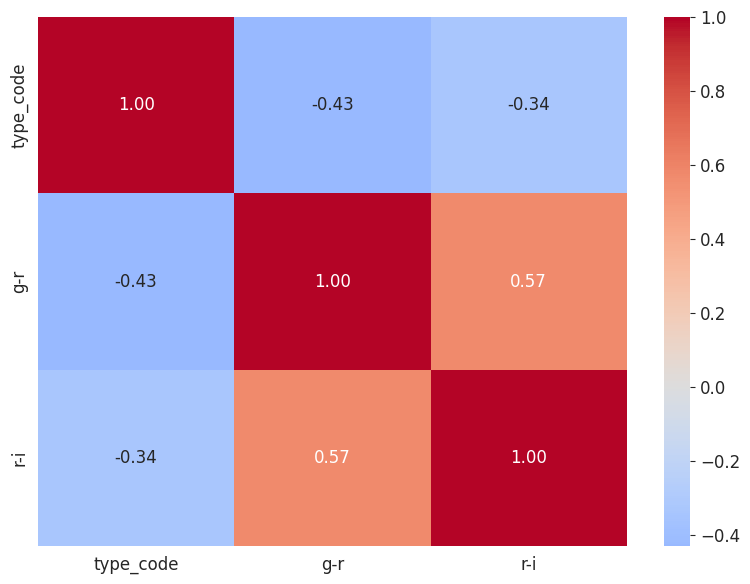

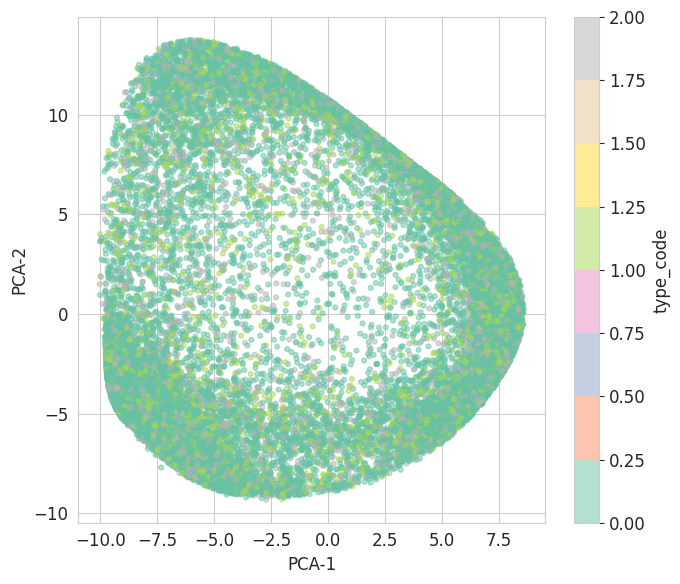

In [63]:
latent_dim = train_tfeat.shape[1]
latent_cols = [f'tfeat_{i}' for i in range(latent_dim)]
base_df = pd.DataFrame(X_train, columns=base_features)
latent_df = pd.DataFrame(train_tfeat, columns=latent_cols)
eda_aug_df = pd.concat([base_df, latent_df], axis=1)
eda_aug_df['type_code'] = y_train

corr_aug = eda_aug_df.corr(numeric_only=True)
selected_cols = corr_aug['type_code'].abs()
selected_cols = selected_cols[selected_cols >= 0.3].index.tolist()
selected_cols = [c for c in selected_cols if c != 'type_code']

if len(selected_cols) == 0:
    print('没有与 type_code 相关性绝对值 >= 0.3 的特征。')
else:
    heatmap_cols = ['type_code'] + selected_cols
    plt.figure(figsize=(max(8, 0.45 * len(heatmap_cols)), max(6, 0.4 * len(heatmap_cols))))
    sns.heatmap(
        corr_aug.loc[heatmap_cols, heatmap_cols],
        cmap='coolwarm',
        center=0,
        annot=True,
        fmt='.2f'
    )
    plt.tight_layout()
    plt.show()

# 隐特征 PCA 可视化
pca = PCA(n_components=2, random_state=42)
tfeat_2d = pca.fit_transform(train_tfeat)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(tfeat_2d[:, 0], tfeat_2d[:, 1], c=y_train, cmap='Set2', alpha=0.5, s=12)
plt.xlabel('PCA-1')
plt.ylabel('PCA-2')
plt.colorbar(scatter, label='type_code')
plt.tight_layout()
plt.show()

In [64]:
gc.collect()
torch.cuda.empty_cache()

In [74]:
# 树模型训练
print('开始树模型训练...')

f2_scorer = make_scorer(fbeta_score, beta=2, average='weighted')
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- RandomForest ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=64,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
).fit(X_train_aug, y_train)
proba_rf_val = rf.predict_proba(X_val_aug)
print(f"RF 验证 F2: {fbeta_score(y_val, rf.predict(X_val_aug), beta=2, average='weighted'):.4f}")

# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=64,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    eval_metric='mlogloss',
    device='cuda'
).fit(X_train_aug, y_train)
proba_xgb_val = xgb.predict_proba(X_val_aug)
print(f"XGB 验证 F2: {fbeta_score(y_val, xgb.predict(X_val_aug), beta=2, average='weighted'):.4f}")

# --- LightGBM ---
lgb = LGBMClassifier(
    n_estimators=200,
    max_depth=64,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    num_leaves=63,
    random_state=42,
    class_weight='balanced',
    verbose=-1
).fit(X_train_aug, y_train)
proba_lgb_val = lgb.predict_proba(X_val_aug)
print(f"LGB 验证 F2: {fbeta_score(y_val, lgb.predict(X_val_aug), beta=2, average='weighted'):.4f}")

开始树模型训练...


/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/par

RF 验证 F2: 0.8367
XGB 验证 F2: 0.8655
LGB 验证 F2: 0.8647


/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [75]:
gc.collect()
torch.cuda.empty_cache()

In [76]:
X_stack = np.hstack([proba_rf_val, proba_xgb_val, proba_lgb_val])
stacker = LogisticRegression(max_iter=1000, C=1.0)
stacker.fit(X_stack, y_val)

proba_ens = stacker.predict_proba(X_stack)
preds = np.argmax(proba_ens, axis=1)
best_f2 = fbeta_score(y_val, preds, beta=2, average='weighted')
print(f"Stacking (LogisticRegression) 验证集 F2: {best_f2:.6f}")

Stacking (LogisticRegression) 验证集 F2: 0.872580


/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/par

各模型在验证集上的性能指标：
       Model  Accuracy  Precision   Recall       F1       F2
     XGBoost  0.868333   0.864680 0.868333 0.863009 0.865540
    LightGBM  0.865000   0.866133 0.865000 0.864779 0.864717
RandomForest  0.838667   0.837873 0.838667 0.835387 0.836689


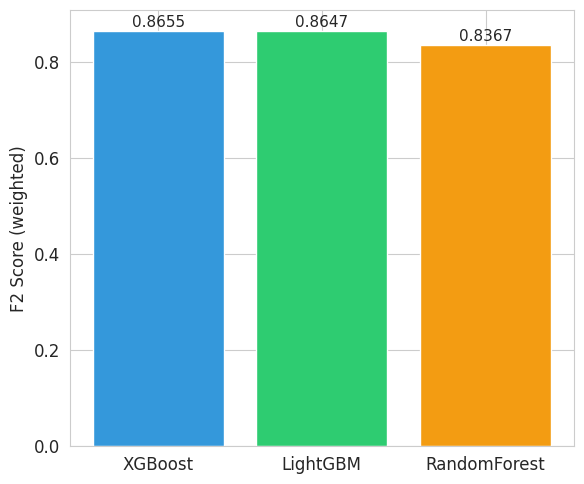

In [77]:
# 1. 获取各模型在验证集上的预测类别
# 树模型（使用拼接后的增强特征）
preds_rf = rf.predict(X_val_aug)
preds_xgb = xgb.predict(X_val_aug)
preds_lgb = lgb.predict(X_val_aug)

# 计算各项指标（加权平均）
models = {
    'RandomForest': preds_rf,
    'XGBoost': preds_xgb,
    'LightGBM': preds_lgb
}

metrics_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'F2'])

for name, preds in models.items():
    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds, average='weighted')
    rec = recall_score(y_val, preds, average='weighted')
    f1 = f1_score(y_val, preds, average='weighted')
    f2 = fbeta_score(y_val, preds, beta=2, average='weighted')
    metrics_df = pd.concat([metrics_df, pd.DataFrame([{
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'F2': f2
    }])], ignore_index=True)

# 按 F2 降序排列
metrics_df = metrics_df.sort_values('F2', ascending=False).reset_index(drop=True)
print("各模型在验证集上的性能指标：")
print(metrics_df.to_string(index=False))

# 绘制 F2 分数对比柱状图
plt.figure(figsize=(6, 5))
bars = plt.bar(metrics_df['Model'], metrics_df['F2'], color=['#3498db', '#2ecc71', '#f39c12', '#9b59b6'])
plt.ylabel('F2 Score (weighted)')

# 在柱顶显示数值
for bar, score in zip(bars, metrics_df['F2']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{score:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [78]:
gc.collect()
torch.cuda.empty_cache()

In [79]:
# 测试集特征准备
X_A = A_fe[base_features].values.astype(np.float32)
X_B = B_fe[base_features].values.astype(np.float32)
X_A_scaled = scaler.transform(X_A).astype(np.float32)
X_B_scaled = scaler.transform(X_B).astype(np.float32)

# 提取第一阶段 Transformer 特征并拼接到测试集
def extract_tfeat_in_batches(pt_model, X_scaled, batch_size=BATCH_SIZE):
    pt_model.eval()
    n = X_scaled.shape[0]
    feats = []
    with torch.no_grad():
        with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
            for i in tqdm(range(0, n, batch_size), desc="Extract"):
                X_batch = X_scaled[i:i+batch_size]
                X_tensor = torch.tensor(X_batch, dtype=torch.float32).to(device)
                feat = pt_model(X_tensor).cpu().numpy()
                feats.append(feat)
        gc.collect()
        torch.cuda.empty_cache()
    return np.concatenate(feats, axis=0)

A_tfeat = extract_tfeat_in_batches(pt_model, X_A_scaled, batch_size=BATCH_SIZE)
B_tfeat = extract_tfeat_in_batches(pt_model, X_B_scaled, batch_size=BATCH_SIZE)

X_A_aug = np.concatenate([X_A, A_tfeat], axis=1)
X_B_aug = np.concatenate([X_B, B_tfeat], axis=1)

# 树模型概率（使用增强特征）
proba_A_rf = rf.predict_proba(X_A_aug)
proba_A_xgb = xgb.predict_proba(X_A_aug)
proba_A_lgb = lgb.predict_proba(X_A_aug)

proba_B_rf = rf.predict_proba(X_B_aug)
proba_B_xgb = xgb.predict_proba(X_B_aug)
proba_B_lgb = lgb.predict_proba(X_B_aug)

Extract:   0%|          | 0/235 [00:00<?, ?it/s]

Extract: 100%|██████████| 235/235 [00:01<00:00, 213.99it/s]
/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/environment/miniconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/environme

In [80]:
gc.collect()
torch.cuda.empty_cache()

In [81]:
# 构造测试集的 stacking 特征
X_test_A_stack = np.hstack([proba_A_rf, proba_A_xgb, proba_A_lgb])
X_test_B_stack = np.hstack([proba_B_rf, proba_B_xgb, proba_B_lgb])

# 用已经训练好的 stacker 预测
proba_A_ens = stacker.predict_proba(X_test_A_stack)
proba_B_ens = stacker.predict_proba(X_test_B_stack)

# 将概率转为类别编号（0,1,2）
preds_A = np.argmax(proba_A_ens, axis=1)
preds_B = np.argmax(proba_B_ens, axis=1)

# 反变换为原始标签（字符串）
y_A_pred = label_encoder.inverse_transform(preds_A)
y_B_pred = label_encoder.inverse_transform(preds_B)

# 保存提交文件
submit_A = pd.DataFrame({'objid': A_fe['objid'], 'type': y_A_pred})
submit_B = pd.DataFrame({'objid': B_fe['objid'], 'type': y_B_pred})
submit_A.to_csv('./A_predict.csv', index=False)
submit_B.to_csv('./B_predict.csv', index=False)

print('集成模型预测文件已保存:')
print('   - A_predict.csv')
print('   - B_predict.csv')

集成模型预测文件已保存:
   - A_predict.csv
   - B_predict.csv
